# 1. Handwriting & Sketching in SolveIt!

This experimental dialog investigates **using a HTML canvas element as an additional input modality to SolveIt**. This is an exciting avenue to explore as it offers another way to 'communicate' with SolveIt.

This could be a great use-case for younger solvers too, so that SolveIt can be used as an engaging learning environment. e.g. Prompt a user to draw a shape, or write out a simple equation, and the LLM offers feedback on the result.

**This really elevates the SolveIt experience if you have a graphics tablet. In addition to just keyboard, and voice, you can now write prose, add complex equations, sketch, and design by hand!**

If this new method of interacting with SolveIt is widely adopted by users then fingers crossed it will make its way into core SolveIt. 🙂

## 1.1 Documentation

We use the [perfect-freehand](https://github.com/steveruizok/perfect-freehand) library (v1.2.3) for pressure-sensitive stroke rendering. The library calculates stroke outlines from input points, which are rendered as filled SVG paths on an HTML canvas.

### Stroke Parameters

The drawing engine exposes several parameters that control stroke appearance:

- **Size** (1-20): Base stroke width in pixels. The UI offers presets from 1px to 20px.

- **Thinning** (default 0.5): How stroke width responds to pressure/velocity. Positive values thin the stroke under pressure; negative values thicken it; zero produces uniform width.

- **Smoothing** (default 0.5): Controls corner softening. Lower values preserve hand wobble for a raw, sketchy feel; higher values round out jagged corners for cleaner curves.

- **Streamline** (default 0.3): Determines cursor lag. Lower values follow the exact path instantly (responsive but potentially jittery); higher values create a trailing effect for fluid, calligraphy-like strokes.

- **Opacity** (10-100%): Stroke transparency, applied per-stroke and preserved in undo/redo.

### Rendering Architecture

The implementation uses an **offscreen canvas pattern** for performance. Strokes are drawn to a buffer canvas, then composited to the visible canvas in a single operation. This avoids flickering during complex redraws.

**Pointer event coalescing** captures intermediate points that would otherwise be lost between frames, producing smoother strokes especially on high-frequency input devices. A `requestAnimationFrame` throttle prevents over-rendering when input arrives faster than display refresh.

### Drawing Modes

Three modes are available:

- **Pen mode**: Standard drawing with current stroke settings
- **Eraser mode**: Removes entire strokes that intersect with the eraser path (uses pixel-based intersection testing)
- **Select mode**: Click and drag to reposition existing strokes or pasted images

### Undo/Redo System

The canvas maintains separate undo and redo stacks that track three action types:

- **stroke**: Adding a new stroke or pasted image
- **move**: Repositioning a stroke or image (stores original position/points)
- **erase**: Deleting strokes (stores references to deleted strokes for restoration)

Clear operations push all current strokes as individual undo entries, making the action fully reversible.

### Export & DPR

Canvas exports at device pixel ratio (DPR) scale for sharp rendering on high-DPI displays. A 450×200 CSS canvas on a 2x display saves as a 900×400 PNG. Images sent to the LLM are therefore higher resolution than they appear in the UI.

### Persistence

Canvas data is stored in `freehand-data/` with dual format:

- `{cid}.json` — Complete stroke data including points, color, size, opacity, and perfect-freehand options per stroke. Images are stored as references to separate files.
- `{cid}.png` — Rendered snapshot at DPR scale for quick preview and LLM analysis
- `{cid}_img_N.png` — Pasted images stored separately, referenced by stroke entries

On load, JSON data rebuilds strokes with full undo support. A settings file (`freehand_settings.json`) tracks the next available canvas ID.

### Canvas Resizing

The canvas can be resized from any edge (top, right, bottom, left) in configurable pixel increments (default 50px, range 10-200px). Resizing from left or top edges automatically shifts all existing strokes to maintain their visual position. Dimensions are constrained between 400×200 and 2000×4000 pixels.

### Image Pasting

Clipboard images are pasted via Ctrl/Cmd+V. The canvas auto-expands to fit large images. A toggle controls whether images paste above or below existing strokes. Each pasted image is saved as a separate PNG file and referenced in the stroke data.

### Solveit Integration

The `upload_freehand_attachment` function bridges the canvas and solveit's AI:

1. Reads the PNG snapshot for the given canvas ID
2. Uploads it as a solveit attachment via the internal API
3. Creates a prompt message with the embedded image
4. Automatically runs the prompt to get LLM feedback

### Styling

Canvas messages are styled via CSS `:has()` selector targeting iframes with `/freehand/` in the src — purple left border and "Canvas:" label. A delegated message listener handles iframe resize events. Both persist across solveit re-renders and browser refreshes.

## 1.2 Use Cases

Here are some initial use-case ideas. If you come up with some more please let me know so I can add to the list!

### 1.2.3 Canvas Use Cases

**Mathematical & Scientific Expression**
- Handwrite complex equations (integrals, summations, matrices) → LLM converts to LaTeX or code
- Draw function graphs → ask "what equation produces this shape?"
- Sketch 3D objects → discuss volume, surface area, or cross-sections
- Draw geometric constructions → prove properties step-by-step
- Draw molecular structures, reaction mechanisms, or lab apparatus setups
- Sketch free-body diagrams, wave patterns, or optical ray diagrams

**Visual Thinking & Problem Solving**
- Help with Advent of Code problem solving
- Mind maps and concept webs for brainstorming
- Decision trees and state diagrams
- Sketch a problem scenario (e.g., "two trains leaving stations...") to visualize
- Draw Venn diagrams for set theory or logic problems
- Flowcharts and algorithm sketches before implementing
- System architecture diagrams

**Design & Prototyping**
- UI/UX wireframes → get feedback or generate HTML/CSS
- Logo sketches → discuss design principles or get SVG code
- Storyboards for animations, videos, or manim scenes
- Game level design sketches
- Floor plans and architectural layouts
- Data visualization mockups → generate matplotlib/plotly code

**Annotation & Analysis**
- Mark up screenshots of code, errors, or documentation
- Annotate paper PDFs while reading — circle key points, add questions
- Highlight and comment on diagrams from textbooks
- Red-pen editing of text screenshots
- Explaining bugs with annotated screenshots

**Learning & Assessment**
- Teacher draws a problem, student solves on canvas, LLM checks work
- "Draw what you think X looks like" — test mental models
- Spelling and handwriting practice with feedback
- Visual quizzes: "label this diagram" or "complete this circuit"
- Geometry proofs with step-by-step diagrams
- Music theory: staff notation, chord diagrams, rhythm patterns
- Anatomy/Biology: label diagrams, draw cell structures, sketch organisms
- Historical maps for geography or history discussions
- Draw circuit diagrams and convert them into technical sketches

**Communication & Expression**
- Sketch when you can't find the right words
- Quick diagrams during pair programming or tutoring
- Visual journaling or reflection
- Doodle-based storytelling
- Language learning: draw scenes and describe them in a target language

**Accessibility & Convenience**
- Handwriting practice for younger learners or non-native scripts
- Quick sketches instead of typing long descriptions
- Drawing for users who find typing difficult

**Professional & Business**
- Sketch org charts or process flows
- Whiteboard-style explanations for remote collaboration
- Quick mockups during client calls
- Kanban boards and project planning sketches

**Creative Arts**
- Character design sketches
- Comic panel layouts
- Perspective and composition studies
- Calligraphy practice with stroke feedback

### 1.2.4 Canvas Use Cases for Younger Solvers

**Early Learning**
- Practice writing letters and numbers → get feedback on formation
- Draw shapes and learn their names
- Trace patterns to develop fine motor skills
- Connect-the-dots style activities

**Math Foundations**
- Draw groups of objects for counting practice
- Sketch number lines to visualize addition and subtraction
- Draw fractions as pie slices or bar models
- Create simple graphs and tally charts

**Reading & Writing**
- Illustrate vocabulary words
- Draw story scenes and narrate what's happening
- Spelling practice with immediate feedback
- Phonics: draw things that start with a certain letter

**Science Exploration**
- Draw the water cycle, life cycles, or food chains
- Sketch plants, animals, or weather observations
- Label body parts or simple diagrams
- Draw "what I think will happen" predictions for experiments

**Creative Play**
- Design imaginary creatures and describe their features
- Draw maps of treasure islands or fantasy worlds
- Create simple comic strips
- Design your own emoji or character

**Games & Puzzles**
- Play pictionary-style guessing games with the LLM
- Draw mazes and challenge the LLM to solve them
- Visual riddles: "What am I drawing?"
- Pattern completion challenges

**Show & Tell**
- Draw something from your day and tell the LLM about it
- Sketch your favorite toy, pet, or place
- Visual diary entries

#  2. FastHTML Implementation

## 2.1 Setup

In [ ]:
from fastcore.utils import *
from fasthtml.common import *
from fasthtml.jupyter import *
from fastlite import *
import fasthtml.components as fc
import httpx

In [ ]:
hdrs = (
    Link(href='https://cdn.jsdelivr.net/npm/daisyui@5', rel='stylesheet', type='text/css'),
    Script(src='https://cdn.jsdelivr.net/npm/@tailwindcss/browser@4'),
    Link(href='https://cdn.jsdelivr.net/npm/daisyui@5/themes.css', rel='stylesheet', type='text/css'),
    Script(src='https://unpkg.com/perfect-freehand@1.2.2/dist/perfect-freehand.js')
)

In [ ]:
app = FastHTML(hdrs=hdrs)
rt = app.route

In [ ]:
def get_preview(app):
    return partial(HTMX, app=app, host=None, port=None)
preview = get_preview(app)

**Idempotent server startup for CRAFT files**

On each kernel start/restart:
1. If nothing is on port 8000 → `xargs -r` does nothing (the `-r` flag means "don't run if no input")
2. If something is on port 8000 → it gets killed, then your server takes over

This ensures the FastHTML server always starts cleanly, regardless of prior state.

In [ ]:
import subprocess

def kill_port(port=8000):
    subprocess.run(f"lsof -ti:{port} | xargs -r kill -9", shell=True)

kill_port()

In [ ]:
# Put this BEFORE creating JupyUvi
import time

# Gracefully stop any existing server in this kernel
if 'srv' in dir() and srv is not None:
    try:
        srv.server.should_exit = True
        time.sleep(0.3)  # Give it time to release the port
    except: pass

srv = JupyUvi(app=app)

## 2.2 Simple Route Test

In [ ]:
@rt
def proc_btn(): return f'hi'

@rt
def testbtn():
    return Div(
        Button('click me', hx_post=proc_btn, id='btn', hx_target='#test', cls='btn'),
        Div(id='test')
    )

In [ ]:
display(testbtn)

<fasthtml.core._mk_locfunc.<locals>._lf>

In [ ]:
preview(testbtn)

## 2.3 Perfect Freehand Canvas

Drawing engine using the perfect-freehand library for beautiful pressure-sensitive strokes. Features a resizable canvas, undo/redo, eraser mode, and stroke persistence.

### 2.3.1 Imports

Core imports for freehand canvas functionality.

In [ ]:
import base64, uuid, json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from dialoghelper import find_msgs, update_msg, add_msg, run_msg
from dialoghelper.core import find_dname, dh_settings

### 2.3.2 Attachment Handling

Functions for uploading canvas images as solveit attachments.

**Setup:**
- Creates a folder called `freehand-data/` to store canvas drawings
- Uses a JSON file (`att_map.json`) as a simple lookup table that remembers which canvas drawings have already been uploaded

**The `upload_freehand_attachment` function:**

1. **Reads the image** — Grabs the PNG file for the given canvas ID from the freehand-data folder

2. **Checks if we've seen this canvas before** — Looks in the map file. If yes, reuses the same attachment ID; if no, creates a new unique ID. This prevents duplicates.

3. **Uploads to solveit** — Sends the image to solveit's internal upload endpoint (port 5001, separate from our FastHTML app on port 8000) via HTTP POST, telling it which dialog to attach it to

4. **Creates a prompt message** — Adds a new prompt to the dialog with the image embedded (using solveit's `attachment:` syntax) and a default question asking the LLM to describe what it sees

5. **Runs the prompt** — Automatically triggers the LLM to respond to the new prompt

So essentially: canvas image → upload to solveit → create prompt with image → ask LLM about it. It's the bridge between the drawing canvas and getting AI feedback on what you drew!

In [ ]:
FREEHAND_DIR = Path('freehand-data'); FREEHAND_DIR.mkdir(exist_ok=True)
FREEHAND_ATT_MAP = Path('freehand-data/att_map.json')

def _load_freehand_att_map(): return json.loads(FREEHAND_ATT_MAP.read_text()) if FREEHAND_ATT_MAP.exists() else {}
def _save_freehand_att_map(m): FREEHAND_ATT_MAP.write_text(json.dumps(m))

def upload_freehand_attachment(cid, img_dir=None, prompt_text='Describe what you see.'):
    "Upload freehand canvas image as attachment and create prompt."
    if img_dir is None: img_dir = FREEHAND_DIR
    img_data = (img_dir/f'{cid}.png').read_bytes()
    att_map = _load_freehand_att_map()
    att_id = att_map.get(cid) or str(uuid.uuid4())
    att_map[cid] = att_id; _save_freehand_att_map(att_map)
    fname = f'pasted_image_{att_id}.png'
    
    files = {'file': (fname, img_data, 'image/png')}
    data = {'id_': '', 'msg_type': 'prompt', 'dlg_name': find_dname().strip('/')}
    # Send attachment to SolveIt server.
    r = httpx.post(f'http://localhost:{dh_settings["port"]}/upload_attachment_', data=data, files=files)

    msg_id = add_msg(content=f"[Canvas {cid}]", msg_type="prompt") if r.status_code != 200 or not r.text else r.json()['id']
    if r.status_code == 200 and r.text: update_msg(id=msg_id, content=f"![{fname}](attachment:{att_id})\n\nThis is canvas `{cid}`. {prompt_text}")
    run_msg(ids=msg_id)
    return msg_id

Some coding improvement suggestions for this section:

**Potential bugs:**
1. **No error handling for file read** — If the PNG file doesn't exist, `read_bytes()` will raise `FileNotFoundError`
2. **No error handling for HTTP request** — Network failures, timeouts, etc. aren't caught
3. **`r.json()['id']`** — Could raise `KeyError` if the response doesn't contain `'id'`

**Inefficiencies:**
1. **Unnecessary save** — The att_map is always saved, even when the `cid` already existed and nothing changed
2. **`find_dname()` called inside function** — If called repeatedly, this could be passed in or cached

**Readability:**
1. The one-liner `msg_id = add_msg(...) if ... else r.json()['id']` is quite dense and mixes success/failure logic in a confusing way

### 2.3.3 Main Route

The `/freehand/{cid}` endpoint — assembles UI components, canvas element, and JavaScript drawing engine.

This section contains two main pieces:

1. **`get_freehand_script(cid)`** — A Python function that returns a large JavaScript module as a string. This JS code handles everything that happens in the browser: drawing strokes with pressure sensitivity, undo/redo, eraser mode, pasting images, resizing the canvas, and saving/loading. The `cid` parameter gets embedded into the script so the canvas knows its unique ID for persistence.

2. **`freehand(cid)` route** — A FastHTML endpoint that builds the complete HTML page. It creates the toolbar (resize, pen/eraser toggle, stroke size picker, color picker, opacity, undo/redo/clear buttons, and the "Show SolveIt" button), the canvas element itself, and a status bar showing dimensions and canvas ID. The JavaScript module from above is included as a `<script>` tag at the end.

In [ ]:
def get_freehand_script(cid: str):
    return f'''
import {{ getStroke }} from 'https://esm.sh/perfect-freehand@1.2.3';

// ─── Constants ───────────────────────────────────────────────────────────────
const DEFAULT_W = 450, DEFAULT_H = 200;
const MIN_W = 400, MAX_W = 2000, MIN_H = 200, MAX_H = 4000;
const TOOLBAR_W = 500, TOOLBAR_H = 80, CANVAS_PAD = 20;
const MIN_RESIZE_STEP = 10, MAX_RESIZE_STEP = 200, DEFAULT_RESIZE_STEP = 50;
const DEFAULT_COLOR = '#000000', EXPORT_BG = '#ffffff';
const MAX_SIZE_INDICATOR = 8;
const PEN_CURSOR = 'url("data:image/svg+xml,<svg xmlns=\\'http://www.w3.org/2000/svg\\' width=\\'6\\' height=\\'6\\'><circle cx=\\'3\\' cy=\\'3\\' r=\\'2\\' fill=\\'none\\' stroke=\\'%23000\\' stroke-width=\\'1\\'/></svg>") 3 3, crosshair';
const EDGES = {{right: [1,0,0,0], left: [1,0,1,0], bottom: [0,1,0,0], top: [0,1,0,1]}};

// ─── Debug Timing ────────────────────────────────────────────────────────────
let _t = 0, _c = 0;
function _log(label) {{
    const now = performance.now();
    if (_t) console.log(label, (now - _t).toFixed(2) + 'ms', 'strokes:', strokes.length);
    _t = now;
    if (++_c % 60 === 0) console.log('--- frame', _c, '---');
}}

// ─── Canvas Setup ────────────────────────────────────────────────────────────
const $ = id => document.getElementById(id);
const cv = $('cv');
const ctx = cv.getContext('2d');
const dpr = window.devicePixelRatio || 1;
let W = DEFAULT_W, H = DEFAULT_H;
const offscreen = document.createElement('canvas');
const offCtx = offscreen.getContext('2d');

applyCanvasSize();
cv.style.cursor = PEN_CURSOR;
cv.style.userSelect = 'none';
cv.style.webkitUserSelect = 'none';
cv.addEventListener('contextmenu', e => e.preventDefault());
ctx.imageSmoothingEnabled = false;
offCtx.imageSmoothingEnabled = false;
let points = [], isDrawing = false, strokes = [], undoStack = [], redoStack = [], rafId = null;
let selectedStroke = null, isDragging = false, dragStart = null;

const freehand = {{
    strokeSize: 1,
    strokeColor: DEFAULT_COLOR,
    strokeOpacity: 1.0,
    mode: 'pen',
    thinning: 0.5,
    smoothing: 0.6,
    streamline: 0.3,
    pasteUnder: false
}};

function applyCanvasSize() {{
    cv.width = W * dpr; cv.height = H * dpr;
    cv.style.width = W + 'px'; cv.style.height = H + 'px';
    ctx.scale(dpr, dpr);
    offscreen.width = W * dpr; offscreen.height = H * dpr;
    offCtx.scale(dpr, dpr);
    $('dims').textContent = W + '×' + H;
    $('resize-dims').textContent = W + '×' + H;
}}

function updateContainerWidth() {{
    document.documentElement.style.setProperty('--canvas-w', W + 'px');
}}

function setStrokeSize(s) {{
    freehand.strokeSize = s;
    const line = $('size-line');
    line.style.height = Math.min(s, MAX_SIZE_INDICATOR) + 'px';
    line.style.borderRadius = (s/2) + 'px';
    line.parentElement.title = 'Stroke size: ' + s + 'px';
    document.activeElement.blur();
}}

function setOpacity(o) {{
    freehand.strokeOpacity = o / 100;
    $('opacity-icon').parentElement.title = 'Stroke opacity: ' + o + '%';
    document.activeElement.blur();
}}

function getSvgPathFromStroke(points, closed = true) {{
    const len = points.length;
    if (len < 4) return '';
    let a = points[0], b = points[1];
    const c = points[2];
    let result = 'M' + a[0].toFixed(2) + ',' + a[1].toFixed(2) + ' Q' + b[0].toFixed(2) + ',' + b[1].toFixed(2) + ' ' + ((b[0]+c[0])/2).toFixed(2) + ',' + ((b[1]+c[1])/2).toFixed(2) + ' T';
    for (let i = 2, max = len - 1; i < max; i++) {{
        a = points[i]; b = points[i + 1];
        result += ((a[0]+b[0])/2).toFixed(2) + ',' + ((a[1]+b[1])/2).toFixed(2) + ' ';
    }}
    if (closed) result += 'Z';
    return result;
}}

function strokeOpts(size, opts, last) {{
    return {{size, thinning: opts?.thinning ?? freehand.thinning, smoothing: opts?.smoothing ?? freehand.smoothing, streamline: opts?.streamline ?? freehand.streamline, simulatePressure: false, last}};
}}

function drawStrokes(ctx) {{
    for (const s of strokes) {{
        if (s.type === 'image' && s.img) {{
            ctx.save();
            ctx.setTransform(1, 0, 0, 1, 0, 0);
            ctx.globalAlpha = s.opacity ?? 1;
            ctx.drawImage(s.img, s.x * dpr, s.y * dpr, s.w * dpr, s.h * dpr);
            ctx.restore();
        }} else if (s.path) {{
            ctx.globalAlpha = s.opacity ?? 1;
            ctx.fillStyle = s.color; ctx.fill(s.path);
        }}
    }}
    ctx.globalAlpha = 1;
}}

function redrawOffscreen() {{
    offCtx.clearRect(0, 0, W, H);
    drawStrokes(offCtx);
}}

function redraw() {{
    ctx.save();
    ctx.setTransform(1, 0, 0, 1, 0, 0);
    ctx.clearRect(0, 0, W * dpr, H * dpr);
    ctx.drawImage(offscreen, 0, 0);
    ctx.restore();    
}}

function undo() {{ 
    if (!undoStack.length) return;
    const action = undoStack.pop();
    
    if (action.type === 'stroke') {{
        // Undo stroke: remove from strokes, push to redo
        strokes = strokes.filter(s => s !== action.stroke);
        redoStack.push(action);
    }} else if (action.type === 'move') {{
        // Undo move: restore old position, save current for redo
        const s = action.stroke;
        if (s.type === 'image') {{
            const currentX = s.x, currentY = s.y;
            s.x = action.oldX;
            s.y = action.oldY;
            redoStack.push({{type: 'move', stroke: s, oldX: currentX, oldY: currentY}});
        }} else {{
            const currentPoints = JSON.parse(JSON.stringify(s.points));
            s.points = action.oldPoints;
            const stroke = getStroke(s.points, strokeOpts(s.size, s.options, true));
            s.path = new Path2D(getSvgPathFromStroke(stroke));
            redoStack.push({{type: 'move', stroke: s, oldPoints: currentPoints}});
        }}
    }} else if (action.type === 'erase') {{
        // Undo erase: re-add deleted strokes
        strokes.push(...action.deletedStrokes);
        redoStack.push(action);
    }}
    redrawOffscreen(); redraw();
}}

function redo() {{ 
    if (!redoStack.length) return;
    const action = redoStack.pop();
    
    if (action.type === 'stroke') {{
        // Redo stroke: add back to strokes
        strokes.push(action.stroke);
        undoStack.push(action);
    }} else if (action.type === 'move') {{
        // Redo move: re-apply move, save current for undo
        const s = action.stroke;
        if (s.type === 'image') {{
            const currentX = s.x, currentY = s.y;
            s.x = action.oldX;
            s.y = action.oldY;
            undoStack.push({{type: 'move', stroke: s, oldX: currentX, oldY: currentY}});
        }} else {{
            const currentPoints = JSON.parse(JSON.stringify(s.points));
            s.points = action.oldPoints;
            const stroke = getStroke(s.points, strokeOpts(s.size, s.options, true));
            s.path = new Path2D(getSvgPathFromStroke(stroke));
            undoStack.push({{type: 'move', stroke: s, oldPoints: currentPoints}});
        }}
    }} else if (action.type === 'erase') {{
        // Redo erase: remove strokes again
        strokes = strokes.filter(s => !action.deletedStrokes.includes(s));
        undoStack.push(action);
    }}
    redrawOffscreen(); redraw();
}}

function clearCanvas() {{ 
    if (!strokes.length) return; 
    // Push all strokes as a single clear action
    for (const s of strokes) undoStack.push({{type: 'stroke', stroke: s}});
    strokes = []; 
    redoStack = [];
    redrawOffscreen(); redraw(); 
}}

async function loadImageEntry(entry) {{
    if (entry.type !== 'image' || entry.img) return;
    const img = new Image();
    img.src = '/freehand_img_file/' + entry.file;
    await new Promise(r => img.onload = r);
    entry.img = img;
}}

function getResizeStep() {{
    const input = $('resize-step');
    return Math.max(MIN_RESIZE_STEP, Math.min(MAX_RESIZE_STEP, parseInt(input?.value) || DEFAULT_RESIZE_STEP));
}}

function resizeEdge(edge, dir) {{
    const step = getResizeStep() * dir;
    const [dw, dh, sx, sy] = EDGES[edge].map(v => v * step);
    const newW = Math.max(MIN_W, Math.min(MAX_W, W + dw));
    const newH = Math.max(MIN_H, Math.min(MAX_H, H + dh));
    const actualDw = newW - W, actualDh = newH - H;
    if (actualDw === 0 && actualDh === 0) return;
    
    // Shift stroke points if extending/cropping from left or top
    if (sx !== 0 || sy !== 0) {{
        const shiftX = sx ? actualDw : 0, shiftY = sy ? actualDh : 0;
        for (const s of strokes) {{
            if (s.type === 'image') {{ s.x += shiftX; s.y += shiftY; }}
            else {{
                s.points = s.points.map(p => [p[0] + shiftX, p[1] + shiftY, p[2]]);
                s.path = new Path2D(getSvgPathFromStroke(getStroke(s.points, strokeOpts(s.size, s.options, true))));
            }}
        }}
    }}
    
    W = newW; H = newH;
    applyCanvasSize();
    redrawOffscreen(); redraw();
    updateResizeBtns();
    updateContainerWidth();
    parent.postMessage({{width: Math.max(TOOLBAR_W, W + CANVAS_PAD), height: H + TOOLBAR_H}}, '*');
    saveCanvas();
}}

function updateResizeBtns() {{
    const lim = {{p: [W >= MAX_W, H >= MAX_H], m: [W <= MIN_W, H <= MIN_H]}};
    ['top','bottom','left','right'].forEach((e, i) => ['p','m'].forEach(d => 
        $(e + '-' + d)?.classList.toggle('btn-disabled', lim[d][i < 2 ? 1 : 0])));
}}

cv.onpointerdown = (e) => {{
    if (e.target !== cv) return;
    e.preventDefault();
    cv.setPointerCapture(e.pointerId);
    
    if (freehand.mode === 'select') {{
        // Hit test strokes in reverse order (top to bottom)
        for (let i = strokes.length - 1; i >= 0; i--) {{
            const s = strokes[i];
            if (s.type === 'image') {{
                if (e.offsetX >= s.x && e.offsetX <= s.x + s.w && e.offsetY >= s.y && e.offsetY <= s.y + s.h) {{
                    selectedStroke = s;
                    isDragging = true;
                    dragStart = {{x: e.offsetX, y: e.offsetY}};
                    // Save state before moving for undo
                    undoStack.push({{type: 'move', stroke: s, oldX: s.x, oldY: s.y}});
                    redoStack = [];
                    return;
                }}
            }} else if (s.points && isNearStroke(s, e.offsetX, e.offsetY, 10)) {{
                selectedStroke = s;
                isDragging = true;
                dragStart = {{x: e.offsetX, y: e.offsetY}};
                // Save state before moving for undo
                undoStack.push({{type: 'move', stroke: s, oldPoints: JSON.parse(JSON.stringify(s.points))}});
                redoStack = [];
                return;
            }}
        }}
        selectedStroke = null;
    }} else {{
        isDrawing = true;
        points = [[e.offsetX, e.offsetY, e.pressure]];

    }}
}};

cv.onpointermove = (e) => {{
    if (freehand.mode === 'select') {{
        if (isDragging && selectedStroke && dragStart) {{
            const dx = e.offsetX - dragStart.x;
            const dy = e.offsetY - dragStart.y;
            
            if (selectedStroke.type === 'image') {{
                selectedStroke.x += dx;
                selectedStroke.y += dy;
            }} else {{
                selectedStroke.points = selectedStroke.points.map(p => [p[0] + dx, p[1] + dy, p[2]]);
                const stroke = getStroke(selectedStroke.points, strokeOpts(selectedStroke.size, selectedStroke.options, true));
                selectedStroke.path = new Path2D(getSvgPathFromStroke(stroke));
            }}
            
            dragStart = {{x: e.offsetX, y: e.offsetY}};
            redrawOffscreen();
            redraw();
        }} else {{
            redraw(); // Redraw to update debug visuals
            // Update cursor on hover in select mode
            let overStroke = false;
            for (let i = strokes.length - 1; i >= 0; i--) {{
                const s = strokes[i];
                if (s.type === 'image') {{
                    if (e.offsetX >= s.x && e.offsetX <= s.x + s.w && e.offsetY >= s.y && e.offsetY <= s.y + s.h) {{
                        overStroke = true;
                        break;
                    }}
                }} else if (s.points && isNearStroke(s, e.offsetX, e.offsetY, 10)) {{
                    overStroke = true;
                    break;
                }}
            }}
            cv.style.cursor = overStroke ? 'grab' : 'default';
        }}
    }} else if (isDrawing) {{
        const events = e.getCoalescedEvents?.() || [e];
        for (const evt of events) {{
            const last = points[points.length - 1];
            if (!last || Math.hypot(evt.offsetX - last[0], evt.offsetY - last[1]) >= 2) {{
                points.push([evt.offsetX, evt.offsetY, evt.pressure]);
            }}
        }}
        if (!rafId) {{
            rafId = requestAnimationFrame(() => {{
                _log('start');
                rafId = null;
                redraw();
                _log('redraw');
                if (points.length > 1) {{
                    const stroke = getStroke(points, strokeOpts(freehand.strokeSize, freehand, false));
                    _log('getStroke');
                    const pathData = getSvgPathFromStroke(stroke);
                    _log('pathData');
                    if (pathData) {{
                        ctx.globalAlpha = freehand.strokeOpacity;
                        ctx.fillStyle = freehand.strokeColor;
                        ctx.fill(new Path2D(pathData));
                        _log('fill');
                        ctx.globalAlpha = 1;
                    }}
                }}
            }});
        }}
    }}
}};

cv.onpointerup = (e) => {{
    if (freehand.mode === 'select') {{
        if (isDragging) {{
            isDragging = false;
            dragStart = null;
            cv.style.cursor = 'default';
        }}
    }} else if (isDrawing) {{
        isDrawing = false;
        if (rafId) {{ cancelAnimationFrame(rafId); rafId = null; }}  // Cancel any pending frame
        const stroke = getStroke(points, strokeOpts(freehand.strokeSize, freehand, true));
        const pathData = getSvgPathFromStroke(stroke);
        if (pathData) {{
            if (freehand.mode === 'eraser') {{
                const eraserPath = new Path2D(pathData);
                const deleted = [];
                strokes = strokes.filter(s => {{ 
                    if (s.type === 'image') {{
                        for (const p of points) {{
                            if (p[0] >= s.x && p[0] <= s.x + s.w && p[1] >= s.y && p[1] <= s.y + s.h) {{ deleted.push(s); return false; }}
                        }}
                        return true;
                    }}
                    const testCtx = offscreen.getContext('2d'); 
                    if (pathsIntersect(eraserPath, s.path, testCtx)) {{ deleted.push(s); return false; }}
                    return true;
                }});
                if (deleted.length) {{ undoStack.push({{type: 'erase', deletedStrokes: deleted}}); redoStack = []; redrawOffscreen(); }}
            }} else {{
                const newStroke = {{path: new Path2D(pathData), color: freehand.strokeColor, size: freehand.strokeSize, opacity: freehand.strokeOpacity, options: {{thinning: freehand.thinning, smoothing: freehand.smoothing, streamline: freehand.streamline}}, points: [...points]}};
                strokes.push(newStroke);
                undoStack.push({{type: 'stroke', stroke: newStroke}});
                redoStack = [];
                // Incremental draw: just add new stroke to offscreen buffer
                offCtx.globalAlpha = newStroke.opacity;
                offCtx.fillStyle = newStroke.color;
                offCtx.fill(newStroke.path);
                offCtx.globalAlpha = 1;
            }}
        }}
        points = [];
        redraw();
    }}
}};

function pathsIntersect(p1, p2, ctx) {{
    ctx.save(); ctx.clearRect(0,0,W,H); ctx.fillStyle='#000'; ctx.fill(p1);
    const d1 = ctx.getImageData(0,0,W*dpr,H*dpr).data;
    ctx.clearRect(0,0,W,H); ctx.fill(p2);
    const d2 = ctx.getImageData(0,0,W*dpr,H*dpr).data;
    ctx.clearRect(0,0,W,H); ctx.restore();
    for (let i=3; i<d1.length; i+=4) if (d1[i]>0 && d2[i]>0) return true;
    return false;
}}

function isNearStroke(stroke, x, y, tolerance) {{
    // Check distance to actual stroke points (more reliable than isPointInPath with DPR)
    if (!stroke.points || stroke.points.length === 0) return false;
    const tolSq = tolerance * tolerance;
    for (const p of stroke.points) {{
        const dx = p[0] - x, dy = p[1] - y;
        if (dx * dx + dy * dy <= tolSq) return true;
    }}
    return false;
}}

function setMode(m) {{
    freehand.mode = m;
    $('penBtn').classList.toggle('btn-active', m==='pen');
    $('eraserBtn').classList.toggle('btn-active', m==='eraser');
    $('selectBtn').classList.toggle('btn-active', m==='select');
    if (m === 'pen') cv.style.cursor = PEN_CURSOR;
    else if (m === 'eraser') cv.style.cursor = 'pointer';
    else if (m === 'select') cv.style.cursor = 'default';
    selectedStroke = null;
    isDragging = false;
}}

function getExportCanvas() {{
    const expCv = document.createElement('canvas');
    expCv.width = W * dpr; expCv.height = H * dpr;
    const expCtx = expCv.getContext('2d');
    expCtx.scale(dpr, dpr);
    expCtx.imageSmoothingEnabled = false;
    expCtx.fillStyle = EXPORT_BG; expCtx.fillRect(0, 0, W, H);
    drawStrokes(expCtx);
    return expCv;
}}

function getCanvasPayload() {{
    const data = {{width: W, height: H, strokes: strokes.map(s => s.type === 'image'
        ? {{type: 'image', file: s.file, x: s.x, y: s.y, w: s.w, h: s.h, opacity: s.opacity}}
        : {{points: s.points, color: s.color, size: s.size, opacity: s.opacity, options: s.options}})}};
    return 'cid={cid}&data=' + encodeURIComponent(JSON.stringify(data)) + '&img=' + encodeURIComponent(getExportCanvas().toDataURL('image/png'));
}}

function postCanvas(endpoint) {{
    fetch(endpoint, {{method: 'POST', headers: {{'Content-Type': 'application/x-www-form-urlencoded'}}, body: getCanvasPayload()}});
}}

function saveCanvas() {{ 
    postCanvas('/save_freehand'); 
    $('status').textContent = 'Saved ✓';
    setTimeout(() => $('status').textContent = '', 2000);
}}

async function loadCanvas() {{
    const r = await fetch('/load_freehand/{cid}');
    if (!r.ok) {{ updateResizeBtns(); updateContainerWidth(); parent.postMessage({{width: Math.max(TOOLBAR_W, W + CANVAS_PAD), height: H + TOOLBAR_H}}, '*'); return; }}
    const data = await r.json();
    const strokesData = data.strokes || [];
    const loadW = data.width || DEFAULT_W, loadH = data.height || DEFAULT_H;
    if (loadW !== W || loadH !== H) {{
        W = loadW; H = loadH;
        applyCanvasSize();
    }}
    updateResizeBtns();
    updateContainerWidth();
    parent.postMessage({{width: Math.max(TOOLBAR_W, W + CANVAS_PAD), height: H + TOOLBAR_H}}, '*');
    // Load image entries first
    await Promise.all(strokesData.filter(s => s.type === 'image').map(s => loadImageEntry(s)));
    strokes = strokesData.map(s => {{
        if (s.type === 'image') return s;
        const stroke = getStroke(s.points, strokeOpts(s.size, s.options, true));
        const pathData = getSvgPathFromStroke(stroke);
        return {{path: new Path2D(pathData), color: s.color, size: s.size, opacity: s.opacity ?? 1, options: s.options, points: s.points}};
    }});
    redrawOffscreen(); redraw();
}}

function askSolveIt() {{
    const promptText = $('solveit-prompt')?.value || 'Describe what you see.';
    const payload = getCanvasPayload() + '&prompt=' + encodeURIComponent(promptText);
    fetch('/ask_freehand', {{method: 'POST', headers: {{'Content-Type': 'application/x-www-form-urlencoded'}}, body: payload}});
}}

// pasteUnder is in freehand object
function togglePasteUnder() {{
    freehand.pasteUnder = !freehand.pasteUnder;
    const btn = $('pasteUnderBtn');
    btn.classList.toggle('btn-active', freehand.pasteUnder);
    btn.title = freehand.pasteUnder ? 'Paste images underneath strokes (ON)' : 'Paste images underneath strokes (OFF)';
}}

document.addEventListener('paste', async e => {{
    const item = [...e.clipboardData.items].find(i => i.type.startsWith('image/'));
    if (!item) return;
    const blob = item.getAsFile();
    const formData = new FormData();
    formData.append('cid', '{cid}');
    formData.append('img', blob);
    const r = await fetch('/save_freehand_img', {{method: 'POST', body: formData}});
    const {{file, w, h}} = await r.json();
    
    // Expand canvas if needed (convert from image pixels to CSS pixels)
    const imgW = Math.round(w / dpr);
    const imgH = Math.round(h / dpr);
    const newW = Math.max(W, imgW), newH = Math.max(H, imgH);
    if (newW !== W || newH !== H) {{
        W = newW; H = newH;
        applyCanvasSize();
        updateResizeBtns();
        updateContainerWidth();
        parent.postMessage({{width: Math.max(TOOLBAR_W, W + CANVAS_PAD), height: H + TOOLBAR_H}}, '*');
    }}
    
    const imgEntry = {{type: 'image', file, x: (W-imgW)/2, y: (H-imgH)/2, w: imgW, h: imgH, img: null}};
    await loadImageEntry(imgEntry);
if (freehand.pasteUnder) strokes.unshift(imgEntry);
    else strokes.push(imgEntry);
    undoStack.push({{type: 'stroke', stroke: imgEntry}});
    redoStack = [];
    redrawOffscreen();
    redraw();
    saveCanvas();
}});

// Close dropdowns on Esc
document.addEventListener('keydown', e => {{
    if (e.key === 'Escape') {{
        document.activeElement.blur();
    }}
}});

Object.assign(freehand, {{undo, redo, clearCanvas, setStrokeSize, setOpacity, setMode, saveCanvas, askSolveIt, resizeEdge, updateResizeBtns, getResizeStep, updateContainerWidth, togglePasteUnder}});
window.freehand = freehand;

// Initialize
loadCanvas();
redraw();
'''

**Issues & suggestions for improvement for the script code:**

1. **Undefined variables in `loadCanvas`** — Lines reference `thinning`, `smoothing`, `streamline` directly instead of `freehand.thinning`, etc.
2. **Memory leak potential** — `rafId` is never cancelled on `pointerup`; if the user lifts quickly mid-frame, the RAF callback still runs with stale data
3. **Missing `pointercancel` handler** — Touch interruptions (e.g., incoming call, system dialog) won't clean up drawing state
4. **Eraser performance** — `pathsIntersect` does full-canvas pixel comparison per stroke. With many strokes, this gets expensive. Consider bounding-box pre-filtering
5. **No bounds checking on paste** — Images can expand canvas to `MAX_W`/`MAX_H` without warning; very large clipboard images could cause issues
6. **`saveCanvas()` called frequently** — Every resize step, every paste. Consider debouncing
7. **Globals via `window.*`** — Works, but fragile. Already uses a single `freehand` object which is good, but some state (`W`, `H`, `strokes`, etc.) lives outside it
8. **Duplicate code** — `document.activeElement.blur()` called twice in `setOpacity()`
9. **Hardcoded eraser cursor** — Eraser mode just uses `'pointer'` which is less intuitive than a custom eraser cursor

In [ ]:
@rt('/freehand/{cid}')
def freehand(cid: str):
    
    return (Style(':root{--canvas-w:450px;} body{margin:0;overflow:auto;} .dropdown:not(:focus-within) > .dropdown-content { pointer-events: none !important; } .dropdown-content a:active, .dropdown-content li:active { transform: none !important; background: inherit !important; }'), Div(
        Div(Div(Button('◲', cls='btn btn-sm text-base w-9 h-9 p-0', tabindex='0', title='Resize canvas'),
                Div(
                    Div(Button('+', id='top-p', onclick='freehand.resizeEdge("top", 1)', cls='btn btn-xs', title='Extend from top'),
                        Button('−', id='top-m', onclick='freehand.resizeEdge("top", -1)', cls='btn btn-xs', title='Crop from top'),
                        cls='flex gap-1 justify-center'),
                    Div(Div(Button('+', id='left-p', onclick='freehand.resizeEdge("left", 1)', cls='btn btn-xs', title='Extend from left'),
                            Button('−', id='left-m', onclick='freehand.resizeEdge("left", -1)', cls='btn btn-xs', title='Crop from left'),
                            cls='flex flex-col gap-1'),
                        Div(Span('450×200', id='resize-dims', cls='text-xs font-mono'), cls='w-16 h-10 border border-gray-300 rounded flex items-center justify-center bg-gray-50'),
                        Div(Button('+', id='right-p', onclick='freehand.resizeEdge("right", 1)', cls='btn btn-xs', title='Extend to right'),
                            Button('−', id='right-m', onclick='freehand.resizeEdge("right", -1)', cls='btn btn-xs', title='Crop from right'),
                            cls='flex flex-col gap-1'),
                        cls='flex gap-2 items-center'),
                    Div(Button('+', id='bottom-p', onclick='freehand.resizeEdge("bottom", 1)', cls='btn btn-xs', title='Extend to bottom'),
                        Button('−', id='bottom-m', onclick='freehand.resizeEdge("bottom", -1)', cls='btn btn-xs', title='Crop from bottom'),
                        cls='flex gap-1 justify-center'),
                    Div(Span('Step:', cls='text-xs'), Input(type='number', id='resize-step', value='50', min='10', max='200', cls='input input-xs w-16 text-center', title='Resize step in pixels'), Span('px', cls='text-xs'), cls='flex gap-1 items-center justify-center mt-2'),
                    cls='dropdown-content menu bg-base-100 rounded-box shadow-lg z-10 p-3 flex flex-col gap-2', tabindex='0'),
                cls='dropdown'),
            Button('✏️', id='penBtn', onclick='freehand.setMode("pen")', cls='btn btn-sm btn-active text-base w-9 h-9 p-0', title='Pen mode'),
            Button('🧽', id='eraserBtn', onclick='freehand.setMode("eraser")', cls='btn btn-sm text-base w-9 h-9 p-0', title='Eraser mode'),
            Button('✋', id='selectBtn', onclick='freehand.setMode("select")', cls='btn btn-sm text-base w-9 h-9 p-0', title='Select and move strokes'),
            Div(Button(Span('', id='size-line', style='display:inline-block; width:20px; height:1px; background:#000; vertical-align:middle;'), cls='btn btn-sm btn-ghost px-1', tabindex='0', title='Stroke size: 1px'),
                Ul(*[Li(A(Div(Span('', style=f'display:inline-block; width:30px; height:{s}px; background:#000; border-radius:{s//2}px;'),
                             Span(f'{s}px', cls='ml-2 text-xs font-mono'), cls='flex items-center'),
                        onclick=f'freehand.setStrokeSize({s})', cls='active:!bg-transparent active:!text-current')) for s in [1, 2, 3, 4, 5, 8, 10, 15, 20]],
                   cls='dropdown-content menu bg-base-100 rounded-box shadow-lg z-10 p-1.5', tabindex='0'),
                cls='dropdown'),
            Div(Button(Span('', id='color-dot', style='background:#000000; width:12px; height:12px; border-radius:50%; display:inline-block;'), cls='btn btn-sm btn-ghost px-1', tabindex='0', title='Stroke color'),
                Ul(*[Li(A(Span('', style=f'background:{c}; width:12px; height:12px; border-radius:50%; display:inline-block;'),
                         onclick=f"freehand.strokeColor='{c}'; document.getElementById('color-dot').style.background='{c}'; document.activeElement.blur();", cls='active:!bg-transparent active:!text-current'))
                     for c in ['#000000', '#ef4444', '#f97316', '#eab308', '#22c55e', '#3b82f6', '#8b5cf6', '#ec4899']],
                   cls='dropdown-content menu bg-base-100 rounded-box shadow-lg z-10 p-2', tabindex='0'),
                cls='dropdown'),
            Div(Button(Span('💧', id='opacity-icon', style='font-size:14px'), cls='btn btn-sm btn-ghost px-1', tabindex='0', title='Stroke opacity: 100%'),
                Ul(*[Li(A(Div(Span('', style=f'background:rgba(0,0,0,{o/100}); width:12px; height:12px; display:inline-block; border:1px solid #ccc;'),
                             Span(f'{o}%', cls='ml-2 text-xs font-mono'), cls='flex items-center'),
                        onclick=f'freehand.setOpacity({o})', cls='active:!bg-transparent active:!text-current')) for o in [100, 75, 50, 25, 10]],
                   cls='dropdown-content menu bg-base-100 rounded-box shadow-lg z-10 p-1.5', tabindex='0'),
                cls='dropdown'),
            Button('⤵', id='pasteUnderBtn', onclick='freehand.togglePasteUnder()', cls='btn btn-sm btn-ghost px-1', title='Paste images underneath strokes (click to toggle)'),
            Button('Undo', onclick='freehand.undo()', cls='btn btn-xs', title='Undo last stroke'),
            Button('Redo', onclick='freehand.redo()', cls='btn btn-xs', title='Redo last undone stroke'),
            Button('Clear', onclick='freehand.clearCanvas()', cls='btn btn-xs', title='Clear entire canvas'),
            Button('💾', onclick='freehand.saveCanvas()', cls='btn btn-sm btn-ghost text-base w-9 h-9 p-0', title='Save canvas to disk'),
            Div(Button('💬', cls='btn btn-sm btn-ghost text-base w-9 h-9 p-0', tabindex='0', title='Change LLM text prompt'),
                Div(Textarea('Describe what you see.', id='solveit-prompt', cls='textarea textarea-bordered w-64 h-20 text-sm mb-2', placeholder='Enter prompt for SolveIt...'),
                    Button('Send', onclick='freehand.askSolveIt(); document.activeElement.blur();', cls='btn btn-sm btn-primary w-full'),
                    cls='dropdown-content menu bg-base-100 rounded-box shadow-lg z-10 p-3', tabindex='0'),
                cls='dropdown dropdown-end'),
            Button('📚', onclick='freehand.askSolveIt()', cls='btn btn-sm btn-ghost text-base w-9 h-9 p-0', title='Submit canvas content to SolveIt'),
            cls='flex gap-0.5 items-center', style='touch-action:auto;'),
        Div(
            Div(Div(Canvas(id='cv', style='background:#fff;touch-action:none;display:block;width:450px;height:200px;cursor:crosshair;'), cls='border-2 border-b-0 border-gray-300', style='width: calc(var(--canvas-w) + 4px);'),
                Div(Div(Span('450×200', id='dims', cls='pr-2 mr-2 border-r border-gray-300 text-xs font-mono text-gray-500'),
                        Span(cid, cls='text-xs font-mono text-gray-400'), cls='flex items-center'),
                    Span(id='status', cls='text-xs text-gray-500 ml-auto'),
                    cls='flex items-center gap-2 px-3 py-1.5 bg-gray-50 border-2 border-t-0 border-gray-300 min-h-6', style='width: calc(var(--canvas-w) + 4px);'),
                cls='flex flex-col w-fit'),
            cls='inline-block'),
        cls='flex flex-col gap-2 mt-1'),
        Script(get_freehand_script(cid), type='module')
    )

### 2.3.4 Storage & Persistence

Save/load routes and file management for freehand canvases.

In [ ]:
FREEHAND_SETTINGS = FREEHAND_DIR / 'freehand_settings.json'

def _load_freehand_settings():
    if FREEHAND_SETTINGS.exists():
        return json.loads(FREEHAND_SETTINGS.read_text())
    return {"next_id": 1}

def _save_freehand_settings(settings):
    FREEHAND_SETTINGS.write_text(json.dumps(settings))

def _freehand_files(): return sorted(FREEHAND_DIR.glob('c*.json'))
def list_freehand(): return [p.stem for p in _freehand_files()]
def next_freehand_id():
    settings = _load_freehand_settings()
    cid = settings["next_id"]
    settings["next_id"] = cid + 1
    _save_freehand_settings(settings)
    return cid

@rt('/save_freehand', methods=['POST'])
async def save_freehand(cid: str, data: str, img: str):
    (FREEHAND_DIR/f'{cid}.json').write_text(data)
    if img: (FREEHAND_DIR/f'{cid}.png').write_bytes(base64.b64decode(img.split(',')[1]))
    return f'✓ Saved {cid}'

@rt('/ask_freehand', methods=['POST'])
async def ask_freehand(cid: str, data: str, img: str, prompt: str = 'Describe what you see.'):
    (FREEHAND_DIR/f'{cid}.json').write_text(data)
    (FREEHAND_DIR/f'{cid}.png').write_bytes(base64.b64decode(img.split(',')[1]))
    upload_freehand_attachment(cid, prompt_text=prompt)
    return f'Analyzing {cid}...'

@rt('/load_freehand/{cid}')
def load_freehand(cid: str):
    p = FREEHAND_DIR/f'{cid}.json'
    if not p.exists(): return Response(status_code=404)
    return Response(p.read_text(), media_type='application/json')

@rt('/freehand_img/{cid}')
def freehand_img(cid: str):
    p = FREEHAND_DIR/f'{cid}.png'
    if not p.exists(): return Response(status_code=404)
    return Response(p.read_bytes(), media_type='image/png')

@rt('/save_freehand_img', methods=['POST'])
async def save_freehand_img(cid: str, img: UploadFile):
    existing = list(FREEHAND_DIR.glob(f'{cid}_img_*.png'))
    n = len(existing)
    fname = f'{cid}_img_{n}'
    path = FREEHAND_DIR / f'{fname}.png'
    data = await img.read()
    path.write_bytes(data)
    im = Image.open(path)
    return {'file': fname, 'w': im.width, 'h': im.height}

@rt('/freehand_img_file/{fname}')
def freehand_img_file(fname: str):
    p = FREEHAND_DIR / f'{fname}.png'
    if not p.exists(): return Response(status_code=404)
    return Response(p.read_bytes(), media_type='image/png')


def add_freehand(cid=None):
    if cid is None: cid = f'c{next_freehand_id()}'
    if not str(cid).startswith('c'): cid = f'c{cid}'
    display(preview(f'/freehand/{cid}'))

Suggestions for improvement.

**Potential bugs:**
1. **Path traversal risk** — `cid` and `fname` aren't validated. A malicious input like `../../etc/passwd` could escape the directory (though `FREEHAND_DIR/` prefix helps somewhat)
2. **Race condition** — `save_freehand_img` counts existing files to pick the next number. Two concurrent pastes could get the same `n`
3. **Fragile parsing** — `img.split(',')[1]` assumes valid data URL format; crashes if malformed

**Inefficiencies:**
1. **`next_freehand_id()`** — Globs and parses all filenames every call. With many canvases, this adds up
2. **Duplicate save logic** — `save_freehand` and `ask_freehand` repeat the same JSON/PNG write code
3. **Image not explicitly closed** — `Image.open(path)` in `save_freehand_img` relies on GC to close the file handle

**Missing:**
1. No error handling for file operations
2. No JSON validation before writing

### 2.3.5 Dialog Integration

Functions to add canvas messages and inject UI into solveit.

In [ ]:
def add_freehand_note(cid: str):
    "Add a freehand canvas to a new note message."
    if not str(cid).startswith('c'): cid = f'c{cid}'
    # Constants matching JS
    TOOLBAR_W, TOOLBAR_H, CANVAS_PAD = 500, 80, 20
    DEFAULT_W, DEFAULT_H = 450, 200
    # Read dimensions from saved canvas if exists
    json_path = FREEHAND_DIR / f'{cid}.json'
    if json_path.exists():
        data = json.loads(json_path.read_text())
        if isinstance(data, dict):
            w, h = data.get('width', DEFAULT_W), data.get('height', DEFAULT_H)
        else:
            w, h = DEFAULT_W, DEFAULT_H
    else:
        w, h = DEFAULT_W, DEFAULT_H
    iframe_w = max(TOOLBAR_W, w + CANVAS_PAD)
    iframe_h = h + TOOLBAR_H
    iframe = f'<div style="display: inline-block;"><iframe src="/freehand/{cid}" scrolling="no" style="width: {iframe_w}px; height: {iframe_h}px; border: none;"></iframe></div>'
    return add_msg(content=iframe, msg_type='note', placement='at_end')

@rt('/add_canvas_btn', methods=['POST'])
def add_canvas_btn():
    cid = f'c{next_freehand_id()}'
    add_freehand_note(cid)
    return f'Added {cid}'

In [ ]:
%%js
(function() {
    // Add styles if not present
    if (!document.getElementById('canvas-styles')) {
        const style = document.createElement('style');
        style.id = 'canvas-styles';
        style.textContent = `
            div.msg-card:has(iframe[src*="/freehand/"]) { border-left-color: #9b59b6 !important; }
            div.msg-card:has(iframe[src*="/freehand/"]) .uk-card-header p { visibility: hidden; position: relative; }
            div.msg-card:has(iframe[src*="/freehand/"]) .uk-card-header p::after { content: "Canvas:"; visibility: visible; position: absolute; left: 0; }
        `;
        document.head.appendChild(style);
    }
    
    // Single delegated listener for all canvas iframes
    if (!window._freehandListenerAdded) {
        window.addEventListener('message', function(e) {
            for (const frame of document.querySelectorAll('iframe[src*="/freehand/"]')) {
                if (e.source === frame.contentWindow) {
                    if (e.data.width) frame.style.width = e.data.width + 'px';
                    if (e.data.height) frame.style.height = e.data.height + 'px';
                    break;
                }
            }
        });
        window._freehandListenerAdded = true;
    }
    
    function addCanvasButton() {
        if (document.getElementById('tabh-canvas')) return;
        const tabs = document.querySelector('ul.uk-tab');
        if (tabs) {
            tabs.insertAdjacentHTML('beforeend', '<li id="tabh-canvas" class="tabh" uk-tooltip="Add Canvas" hx-post="/add_canvas_btn" hx-swap="none"><a href="#">Canvas</a></li>');
            htmx.process(document.getElementById('tabh-canvas'));
        }
    }
    
    // Initial check with polling for page load
    function check() {
        if (document.querySelector('ul.uk-tab')) addCanvasButton();
        else setTimeout(check, 100);
    }
    check();
    
    // MutationObserver to handle solveit re-renders
    new MutationObserver(addCanvasButton).observe(document.body, {childList: true, subtree: true});
})();

<IPython.core.display.Javascript object>

### 2.3.6 Utilities

In [ ]:
def view_freehand(cid='c1'):
    "Display a saved freehand canvas image."
    p = FREEHAND_DIR / f'{cid}.png'
    if not p.exists(): raise FileNotFoundError(f"Canvas '{cid}' not found")
    return Image.open(p)

def view_all_freehand(cols=3):
    "Display all saved freehand canvas images in a grid."
    pngs = sorted(FREEHAND_DIR.glob('c*.png'))
    pngs = [p for p in pngs if '_img_' not in p.stem]  # Exclude pasted images
    if not pngs: return print("No saved canvases found.")
    rows = (len(pngs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 2.5*rows))
    axes = [axes] if len(pngs) == 1 else axes.flat
    for ax, p in zip(axes, pngs): ax.imshow(Image.open(p)); ax.set_title(p.stem); ax.axis('off')
    for ax in axes[len(pngs):]: ax.axis('off')
    plt.tight_layout(); plt.show()

def analyze_freehand(cid: str):
    "Analyze a saved freehand canvas image by its ID (e.g. 'c1', 'c2')."
    if not (FREEHAND_DIR / f'{cid}.png').exists(): raise FileNotFoundError(f"Canvas '{cid}' not found")
    upload_freehand_attachment(cid)
    return f"Image {cid} uploaded for analysis."

In [ ]:
def measure_canvas_size(cid='c1'):
    "Measure JSON stroke data and PNG image sizes for a canvas."
    json_path = FREEHAND_DIR / f'{cid}.json'
    png_path = FREEHAND_DIR / f'{cid}.png'
    
    results = {'cid': cid}
    
    if json_path.exists():
        json_bytes = len(json_path.read_bytes())
        results['json_kb'] = round(json_bytes / 1024, 2)
    
    if png_path.exists():
        png_bytes = len(png_path.read_bytes())
        b64_bytes = len(base64.b64encode(png_path.read_bytes()))
        results['png_kb'] = round(png_bytes / 1024, 2)
        results['png_b64_kb'] = round(b64_bytes / 1024, 2)
    
    # Check for pasted images
    pasted = list(FREEHAND_DIR.glob(f'{cid}_img_*.png'))
    if pasted:
        pasted_total = sum(p.stat().st_size for p in pasted)
        pasted_b64 = sum(len(base64.b64encode(p.read_bytes())) for p in pasted)
        results['pasted_count'] = len(pasted)
        results['pasted_kb'] = round(pasted_total / 1024, 2)
        results['pasted_b64_kb'] = round(pasted_b64 / 1024, 2)
    
    return results

Delete all canvas data.

In [ ]:
# import shutil
# shutil.rmtree(FREEHAND_DIR)
# FREEHAND_DIR.mkdir(exist_ok=True)

### 2.3.7 Canvas Tools

Canvas Tools:
- &`add_freehand_note`

General enhancements for future work.

**Performance:**
1. **Debounce `saveCanvas()`** — Currently fires on every resize step and paste. A simple 500ms debounce would reduce server load significantly
2. **Bounding-box pre-filter for eraser** — Before doing expensive pixel intersection tests, check if stroke bounding boxes even overlap. This could skip 90%+ of comparisons
3. **Cancel pending RAF on pointerup** — Add `if (rafId) { cancelAnimationFrame(rafId); rafId = null; }` to prevent stale frame renders

**Stroke Quality:**
1. **Adjust `thinning` based on input device** — Stylus users benefit from higher thinning (0.5-0.7), while mouse users often prefer lower (0.2-0.3) since there's no real pressure data
2. **Add start/end taper options** — perfect-freehand supports `start: {taper: true}` and `end: {taper: true}` for calligraphy-style strokes
3. **Minimum distance filtering** — Skip points that are too close together (< 2px) to reduce jitter without losing detail

**UX Quick Wins:**
1. **Keyboard shortcuts** — `Z` for undo, `Y` for redo, `E` for eraser toggle, `[`/`]` for stroke size
2. **Custom eraser cursor** — Show a circle sized to match the stroke width
3. **Visual mode indicator** — Tint the canvas border or show a subtle overlay when in eraser mode

# 3. Usage Instructions

**1. Adding a Canvas Message**

Run all messages and you should see a new **Canvas** button next to the familiar Code, Note, Prompt, and Raw message buttons. Click this to add a new Canvas message to your dialog. You can also ask the LLM to add a Canvas message for you or use `add_freehand_note('c1')` passing in the ID of the canvas you want to edit/create.

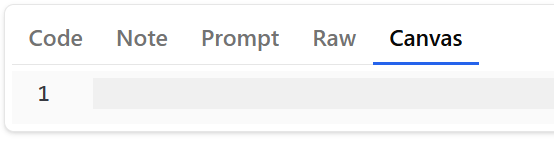

Once added the Canvas message should look like this.

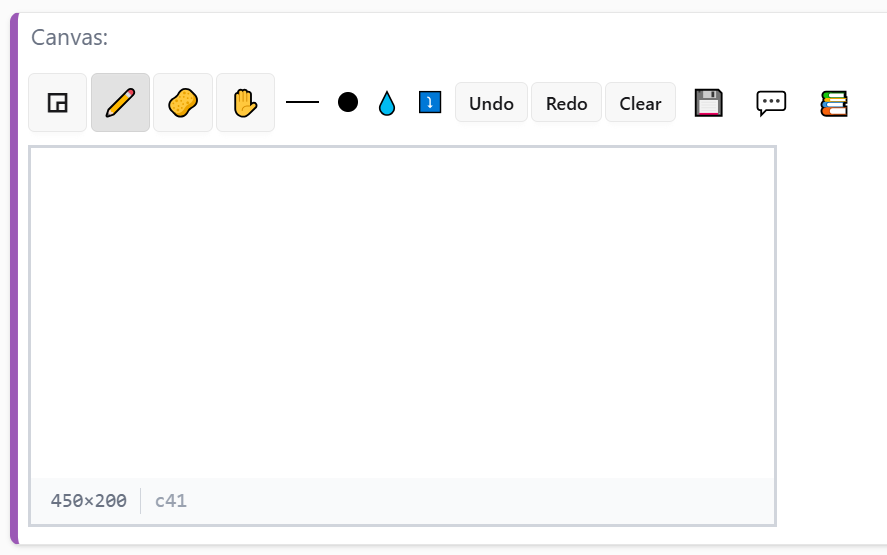

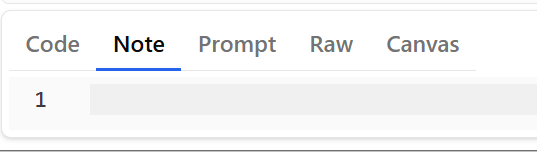

**2. Basic Usage**

Draw inside the canvas area to create sketches, write text, or equations etc. Click the Save button to write the canvas contents to disk so that if you do a browser refresh or restart the kernel your canvas content is restored.

You can also click the SolveIt icon in the Canvas toolbar to submit the canvas to the LLM so it can see the content and respond. Note that this performs a save operation too so you don't need to save manually when submitting to the LLM.

**3. Toolbar Features**

**Canvas Resize**

The first toolbar icon allows you to dynamically resize the canvas drawing area. The default size is deliberately kept fairly small so that it doesn't make the dialog too long if it contains multiple Canvas messages.

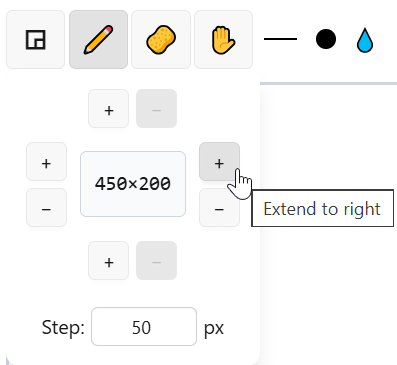

You can resize the canvas by adding a fixed amount of pixels to the top, right, bottom, or left of the current canvas area. The default amount of pixels added each time is 50px but this can be changed in the dropdown menu.

**Drawing Modes**
The next three icons control the canvas *mode*. Pen mode allows you to draw on the canvas, erase mode allows you to delete strokes, and move mode allows you to move existing strokes (or pasted screenshots) to a new location in the canvas.

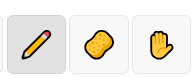

**Stroke Settings**
Next come the stroke settings where you can click to select the stroke thickness, color, and opacity.

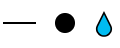

**Pasting Images**
You can paste in screenshots to the canvas by pressing `Ctrl+V` on Windows, or `Cmd+V` on macOS. There is a toolbar icon that allows you to set pasting behind current canvas strokes, or on top.

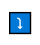

**Undo, Redo, and Clear**
The next three buttons allow you to revert stroke operations, redo them, or clear the canvas completely.

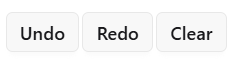

**Save and Submit to LLM**
The last three toolbar icons allow you to save the canvas content to disk, customise the default LLM prompt, or submit the canvas to the LLM (this also performs a save operation).

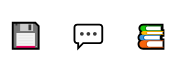
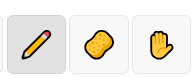

**4. Misc**

**Status Bar**
The status bar always shows the current canvas size, along with the canvas ID.

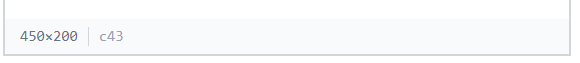

# 4. Testing